# ANALIZA DANYCH Z ZEGARKA APPLE WATCH


## Podstawowe informacje o pliku:

* Plik jest pobierany z aplikacji Zdrowie (Apple Health) na telefonie
* format: XML
* struktura: hierarchiczna, z wieloma różnymi typami rekordów (Record, Correlation, Workout, ActivitySummary, ClinicalRecord, Audiogram, VisionPrescription)
* zawiera dane dotyczące zdrowia, aktywności, snu, tętna, kroków, itp.
* jest dość duży ponad 700 mb





## TO DO:
1. [x] rozgryźć strukturę pliku xml - pól w nim zawartych - co dokładnie w nim jest
2. [x] sprawdzić pomiar EKG i możliwość ściągnięcia danych
3. [x] napisać kod pythona do wczytania tych danych
4. [x] zastanowić się nad programem ćwiczeń dla osób o różnej kondycji, z pomiarem zegarkiem

In [1]:
%matplotlib inline

from lxml import etree as ET
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np


In [6]:
path = "../../eksport.xml"

In [7]:
# funkcja sprawdzająca jakie są tagi w pliku XML i jakie typy danych są w nich zawarte, żeby wiedzieć co można analizować

def discover_xml_structure(file_path):
    # Słownik: Klucz = Nazwa Tagu, Wartość = Zbiór atrybutów 'type' lub 'workoutActivityType'
    found_structures = {}
    # parsujemy plik XML po kolei, żeby nie ładować go w całości do pamięci RAM
    context = ET.iterparse(file_path, events=("end",))

    for event, elem in context:
        tag_name = elem.tag

        #  dodajemy do slownika jesli nie ma w nim jeszcze danego tagu
        if tag_name not in found_structures:
            found_structures[tag_name] = set()

        # sprawdzamy typy głównych tagów
        sub_type = elem.get("type") or elem.get("workoutActivityType") or "Brak"

        found_structures[tag_name].add(sub_type)

        # Czyścimy RAM
        elem.clear()

    return found_structures

In [8]:
moje_dane = discover_xml_structure(path)

print("Tagi i typy danych w pliku XML:")
for tag, sub_types in moje_dane.items():
    print(f"\n TAG: <{tag}>")
    print(f"   Liczba różnych typów: {len(sub_types)}")
    for st in list(sub_types):
        print(f"     - {st}")

Tagi i typy danych w pliku XML:

 TAG: <ExportDate>
   Liczba różnych typów: 1
     - Brak

 TAG: <Me>
   Liczba różnych typów: 1
     - Brak

 TAG: <Record>
   Liczba różnych typów: 41
     - HKQuantityTypeIdentifierWalkingAsymmetryPercentage
     - HKQuantityTypeIdentifierStairDescentSpeed
     - HKDataTypeSleepDurationGoal
     - HKCategoryTypeIdentifierHeadphoneAudioExposureEvent
     - HKQuantityTypeIdentifierHeartRateVariabilitySDNN
     - HKQuantityTypeIdentifierHeartRateRecoveryOneMinute
     - HKQuantityTypeIdentifierWalkingSpeed
     - HKQuantityTypeIdentifierBasalEnergyBurned
     - HKQuantityTypeIdentifierTimeInDaylight
     - HKQuantityTypeIdentifierWalkingStepLength
     - HKCategoryTypeIdentifierAudioExposureEvent
     - HKQuantityTypeIdentifierDistanceWalkingRunning
     - HKQuantityTypeIdentifierDistanceCycling
     - HKCategoryTypeIdentifierMenstrualFlow
     - HKQuantityTypeIdentifierSixMinuteWalkTestDistance
     - HKQuantityTypeIdentifierAppleExerciseTime
     - HK

Z tych wszystkich tagów najbardziej interesujące dla analizy zdrowia i aktywności są: Record, Workout, ActivitySummary, InstantaneousBeatsPerMinute. To w nich znajdują się konkretne dane dotyczące tętna, kroków, snu, itp. Dlatego skupimy się na tych tagach w dalszej analizie.

In [5]:
important_tags = {
    'Me',"Record", "Workout", "ActivitySummary", "InstantaneousBeatsPerMinute"
}

In [6]:
print(moje_dane)  # wyświetla wszystkie tagi i typy danych, które odkryliśmy w pliku XML w postaci listy

{'ExportDate': {'Brak'}, 'Me': {'Brak'}, 'Record': {'HKQuantityTypeIdentifierDistanceCycling', 'HKQuantityTypeIdentifierBodyMass', 'HKQuantityTypeIdentifierFlightsClimbed', 'HKQuantityTypeIdentifierOxygenSaturation', 'HKQuantityTypeIdentifierWaistCircumference', 'HKQuantityTypeIdentifierHeartRateRecoveryOneMinute', 'HKCategoryTypeIdentifierAppleStandHour', 'HKQuantityTypeIdentifierAppleStandTime', 'HKQuantityTypeIdentifierWalkingStepLength', 'HKDataTypeSleepDurationGoal', 'HKQuantityTypeIdentifierEnvironmentalSoundReduction', 'HKQuantityTypeIdentifierStairDescentSpeed', 'HKQuantityTypeIdentifierWalkingAsymmetryPercentage', 'HKQuantityTypeIdentifierEnvironmentalAudioExposure', 'HKQuantityTypeIdentifierStairAscentSpeed', 'HKQuantityTypeIdentifierHeartRateVariabilitySDNN', 'HKCategoryTypeIdentifierHighHeartRateEvent', 'HKQuantityTypeIdentifierHeight', 'HKQuantityTypeIdentifierBasalEnergyBurned', 'HKQuantityTypeIdentifierWalkingSpeed', 'HKQuantityTypeIdentifierAppleExerciseTime', 'HKQuanti

In [7]:
# Do dalszej analizy struktury rekordów wypisujemy każdy znaleziony typ rekordu

diff_types = set()
for event, elem in ET.iterparse(path, events=("end",)):
    if elem.tag in important_tags:
        typ = elem.get("type")  or elem.get("workoutActivityType") or elem.tag

        if typ not in diff_types: #jeśli jeszcze nie wypisaliśmy tego typu, to go wypisujemy
            print(f"\n TYP: {typ}")
            print(f"   ATRYBUTY ELEMENTU: {elem.attrib}")
            if 'sourceName' in elem.attrib and 'Apple' in elem.attrib.get('sourceName', ''): # bierzemy tylko dane z zegarka żeby uniknąć nieścisłości
                print(f"   Atrybuty: {elem.attrib}")


                children = list(elem)
                if children:    # jeśli element ma dzieci, to wypisujemy je
                    for child in children:
                        print(f"   typ: <{child.tag}> atrybuty: {child.attrib}")
            diff_types.add(typ)



        elem.clear()


 TYP: Me
   ATRYBUTY ELEMENTU: {'HKCharacteristicTypeIdentifierDateOfBirth': '2006-03-02', 'HKCharacteristicTypeIdentifierBiologicalSex': 'HKBiologicalSexFemale', 'HKCharacteristicTypeIdentifierBloodType': 'HKBloodTypeNotSet', 'HKCharacteristicTypeIdentifierFitzpatrickSkinType': 'HKFitzpatrickSkinTypeNotSet', 'HKCharacteristicTypeIdentifierCardioFitnessMedicationsUse': 'Brak'}

 TYP: HKQuantityTypeIdentifierHeight
   ATRYBUTY ELEMENTU: {'type': 'HKQuantityTypeIdentifierHeight', 'sourceName': 'FitnessOnline', 'sourceVersion': '206', 'unit': 'cm', 'creationDate': '2025-08-12 12:58:06 +0200', 'startDate': '2025-08-12 12:58:05 +0200', 'endDate': '2025-08-12 12:58:05 +0200', 'value': '163'}

 TYP: HKQuantityTypeIdentifierBodyMass
   ATRYBUTY ELEMENTU: {'type': 'HKQuantityTypeIdentifierBodyMass', 'sourceName': 'Zdrowie', 'sourceVersion': '14.7.1', 'unit': 'kg', 'creationDate': '2021-09-06 11:46:43 +0200', 'startDate': '2021-09-06 11:46:00 +0200', 'endDate': '2021-09-06 11:46:00 +0200', 'val

In [8]:
print(diff_types)
print(len(diff_types)) # liczba typów

{'HKQuantityTypeIdentifierDistanceCycling', 'HKWorkoutActivityTypeStairClimbing', 'HKWorkoutActivityTypeElliptical', 'HKQuantityTypeIdentifierBodyMass', 'HKQuantityTypeIdentifierFlightsClimbed', 'HKQuantityTypeIdentifierOxygenSaturation', 'HKQuantityTypeIdentifierWaistCircumference', 'HKQuantityTypeIdentifierHeartRateRecoveryOneMinute', 'HKCategoryTypeIdentifierAppleStandHour', 'HKQuantityTypeIdentifierAppleStandTime', 'HKQuantityTypeIdentifierWalkingStepLength', 'HKDataTypeSleepDurationGoal', 'HKQuantityTypeIdentifierEnvironmentalSoundReduction', 'HKQuantityTypeIdentifierStairDescentSpeed', 'HKQuantityTypeIdentifierWalkingAsymmetryPercentage', 'HKQuantityTypeIdentifierEnvironmentalAudioExposure', 'HKQuantityTypeIdentifierStairAscentSpeed', 'HKQuantityTypeIdentifierHeartRateVariabilitySDNN', 'HKWorkoutActivityTypeCycling', 'HKCategoryTypeIdentifierHighHeartRateEvent', 'HKWorkoutActivityTypeCardioDance', 'InstantaneousBeatsPerMinute', 'HKQuantityTypeIdentifierHeight', 'HKQuantityTypeIde

In [9]:
# tworzymy krótsze nazwy by było prościej

short_names = {
    # --- CIAŁO / PODSTAWOWE ---
    'HKQuantityTypeIdentifierHeight': 'height',
    'HKQuantityTypeIdentifierBodyMass': 'weight',
    'HKQuantityTypeIdentifierWaistCircumference': 'waist',
    'HKQuantityTypeIdentifierBodyFatPercentage': 'fat_pct',

    # --- SERCE (HEART) ---
    'HKQuantityTypeIdentifierHeartRate': 'hr',
    'HKQuantityTypeIdentifierRestingHeartRate': 'rhr',
    'HKQuantityTypeIdentifierWalkingHeartRateAverage': 'hr_walk_avg',
    'HKQuantityTypeIdentifierHeartRateVariabilitySDNN': 'hrv',
    'HKQuantityTypeIdentifierHeartRateRecoveryOneMinute': 'hrr_1min',
    'HKCategoryTypeIdentifierHighHeartRateEvent': 'hr_high_event',

    # --- AKTYWNOŚĆ / ENERGIA ---
    'HKQuantityTypeIdentifierStepCount': 'steps',
    'HKQuantityTypeIdentifierDistanceWalkingRunning': 'dist_walk',
    'HKQuantityTypeIdentifierDistanceCycling': 'dist_cycle',
    'HKQuantityTypeIdentifierBasalEnergyBurned': 'kcal_basal',
    'HKQuantityTypeIdentifierActiveEnergyBurned': 'kcal_active',
    'HKQuantityTypeIdentifierFlightsClimbed': 'flights',
    'HKQuantityTypeIdentifierAppleExerciseTime': 'exercise_min',
    'HKQuantityTypeIdentifierAppleStandTime': 'stand_min',
    'HKCategoryTypeIdentifierAppleStandHour': 'stand_hr',
    'HKQuantityTypeIdentifierPhysicalEffort': 'effort',
    'HKQuantityTypeIdentifierVO2Max': 'vo2max',

    # --- MOBILNOŚĆ / CHÓD ---
    'HKQuantityTypeIdentifierWalkingSpeed': 'walk_speed',
    'HKQuantityTypeIdentifierWalkingStepLength': 'walk_step_len',
    'HKQuantityTypeIdentifierWalkingAsymmetryPercentage': 'walk_asym',
    'HKQuantityTypeIdentifierWalkingDoubleSupportPercentage': 'walk_dbl_supp',
    'HKQuantityTypeIdentifierStairAscentSpeed': 'stair_up_speed',
    'HKQuantityTypeIdentifierStairDescentSpeed': 'stair_down_speed',
    'HKQuantityTypeIdentifierAppleWalkingSteadiness': 'walk_steadiness',
    'HKQuantityTypeIdentifierSixMinuteWalkTestDistance': 'walk_6min',

    # --- ODDECH / POZIOMY ---
    'HKQuantityTypeIdentifierOxygenSaturation': 'spo2',
    'HKQuantityTypeIdentifierRespiratoryRate': 'resp_rate',

    # --- SEN ---
    'HKCategoryTypeIdentifierSleepAnalysis': 'sleep',
    'HKDataTypeSleepDurationGoal': 'sleep_goal',
    'HKQuantityTypeIdentifierAppleSleepingWristTemperature': 'wrist_temp',

    # --- ŚRODOWISKO / DŹWIĘK ---
    'HKQuantityTypeIdentifierEnvironmentalAudioExposure': 'audio_env',
    'HKQuantityTypeIdentifierHeadphoneAudioExposure': 'audio_hp',
    'HKQuantityTypeIdentifierEnvironmentalSoundReduction': 'sound_red',
    'HKCategoryTypeIdentifierAudioExposureEvent': 'audio_event',
    'HKCategoryTypeIdentifierHeadphoneAudioExposureEvent': 'audio_hp_event',
    'HKQuantityTypeIdentifierTimeInDaylight': 'daylight',

    # --- INNE ---
    'HKCategoryTypeIdentifierMenstrualFlow': 'menstr'
}


In [10]:
def load_one_type(file_path, tag_name, type_name=None):
    """
    Funkcja pobiera dane na podstawie samego tagu np. 'ActivitySummary' lub tagu i typu (np. 'Record' + 'hr') i konwertuje na poprawne typy np. daty, liczby
    """
    health_data = []

    if file_path is None:
        return "Zła ścieżka pliku"

    context = ET.iterparse(file_path, events=("end",))

    for event, elem in context:

        if elem.tag == tag_name:
            current_type = elem.get('type') or elem.get('workoutActivityType')
            if type_name is None or current_type == type_name:
                record = dict(elem.attrib)

                for child in elem:
                    if child.tag == "MetadataEntry":
                        key = child.get('key')
                        if key is not None:
                            record[key] = child.get('value')
                health_data.append(record)

            elem.clear()

    if health_data:
        df = pd.DataFrame(health_data)
        if 'value' in df.columns:
            df['value'] = pd.to_numeric(df['value'], errors='coerce')
        for date_col in ['startDate', 'endDate', 'creationDate']:
            if date_col in df.columns:
                df[date_col] = pd.to_datetime(df[date_col])
        return df
    return pd.DataFrame()

Analiza samych danych tetna


In [11]:
df_hr = load_one_type(path, 'Record', 'HKQuantityTypeIdentifierHeartRate')
df_hr

,type,sourceName,sourceVersion,unit,creationDate,startDate,endDate,value,device,HKMetadataKeyHeartRateMotionContext,HKMetadataKeySyncVersion,HKMetadataKeySyncIdentifier
0,HKQuantityTypeIdentifierHeartRate,Zepp Life,202112101619,count/min,2021-12-24 17:29:14+02:00,2021-12-17 01:00:00+02:00,2021-12-17 01:00:59+02:00,72.0,NaN,NaN,NaN,NaN
1,HKQuantityTypeIdentifierHeartRate,Zepp Life,202112101619,count/min,2021-12-24 17:29:14+02:00,2021-12-17 01:01:00+02:00,2021-12-17 01:01:59+02:00,70.0,NaN,NaN,NaN,NaN
2,HKQuantityTypeIdentifierHeartRate,Zepp Life,202112101619,count/min,2021-12-24 17:29:14+02:00,2021-12-17 01:02:00+02:00,2021-12-17 01:02:59+02:00,70.0,NaN,NaN,NaN,NaN
3,HKQuantityTypeIdentifierHeartRate,Zepp Life,202112101619,count/min,2021-12-24 17:29:14+02:00,2021-12-17 01:03:00+02:00,2021-12-17 01:03:59+02:00,69.0,NaN,NaN,NaN,NaN
4,HKQuantityTypeIdentifierHeartRate,Zepp Life,202112101619,count/min,2021-12-24 17:29:14+02:00,2021-12-17 01:04:00+02:00,2021-12-17 01:04:59+02:00,70.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
422067,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 22:37:52+02:00,2026-04-05 22:31:51+02:00,2026-04-05 22:31:51+02:00,76.0,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",1,NaN,NaN
422068,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 22:43:35+02:00,2026-04-05 22:37:49+02:00,2026-04-05 22:37:49+02:00,74.0,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",1,NaN,NaN
422069,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 22:45:34+02:00,2026-04-05 22:43:16+02:00,2026-04-05 22:43:16+02:00,72.0,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",0,NaN,NaN
422070,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 22:51:13+02:00,2026-04-05 22:45:26+02:00,2026-04-05 22:45:26+02:00,76.0,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",1,NaN,NaN


In [12]:
print(df_hr.columns)
print(df_hr.head())
print(df_hr.describe())

Index(['type', 'sourceName', 'sourceVersion', 'unit', 'creationDate',
       'startDate', 'endDate', 'value', 'device',
       'HKMetadataKeyHeartRateMotionContext', 'HKMetadataKeySyncVersion',
       'HKMetadataKeySyncIdentifier'],
      dtype='object')
                                type sourceName sourceVersion       unit  \
0  HKQuantityTypeIdentifierHeartRate  Zepp Life  202112101619  count/min   
1  HKQuantityTypeIdentifierHeartRate  Zepp Life  202112101619  count/min   
2  HKQuantityTypeIdentifierHeartRate  Zepp Life  202112101619  count/min   
3  HKQuantityTypeIdentifierHeartRate  Zepp Life  202112101619  count/min   
4  HKQuantityTypeIdentifierHeartRate  Zepp Life  202112101619  count/min   

               creationDate                 startDate  \
0 2021-12-24 17:29:14+02:00 2021-12-17 01:00:00+02:00   
1 2021-12-24 17:29:14+02:00 2021-12-17 01:01:00+02:00   
2 2021-12-24 17:29:14+02:00 2021-12-17 01:02:00+02:00   
3 2021-12-24 17:29:14+02:00 2021-12-17 01:03:00+02:00   
4 2

Czyścimy  dane - usuwamy kolumny w których wszystkie wartości sa nan

In [13]:
df_hr = df_hr.dropna(axis=1, how='all')

In [14]:
# Usuwamy konkretne kolumny techniczne, których nie potrzebujemy do analizy tętna
df_hr = df_hr.drop(columns=['HKMetadataKeySyncVersion', 'HKMetadataKeySyncIdentifier'], errors='ignore')

In [15]:
print(df_hr.columns)

Index(['type', 'sourceName', 'sourceVersion', 'unit', 'creationDate',
       'startDate', 'endDate', 'value', 'device',
       'HKMetadataKeyHeartRateMotionContext'],
      dtype='object')


In [16]:
# Usuwamy rekordy, które mają IDENTYCZNY start, koniec I wartość
df_hr = df_hr.drop_duplicates(subset=['startDate', 'endDate', 'value'])
print(f"Usunięto {len(df_hr) - len(df_hr)} idealnych duplikatów.")

Usunięto 0 idealnych duplikatów.


In [17]:
# bierzemy dane pobierane tylko z zegarka
df = df_hr[df_hr['sourceName'].str.contains('Apple', na=False)]
# Wywalamy rekordy, gdzie koniec jest przed początkiem i jakieś błędne
df = df[df['endDate'] >= df['startDate']]
# indeksujemy po dacie poczatkowej żeby można było zrobić resampling
df = df.set_index('startDate')

In [18]:
display(df.tail(100))

,type,sourceName,sourceVersion,unit,creationDate,endDate,value,device,HKMetadataKeyHeartRateMotionContext
startDate,,,,,,,,,
2026-04-05 21:27:10+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 21:27:14+02:00,2026-04-05 21:27:10+02:00,143.0,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",2
2026-04-05 21:27:18+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 21:27:19+02:00,2026-04-05 21:27:18+02:00,147.0,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",2
2026-04-05 21:27:23+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 21:27:24+02:00,2026-04-05 21:27:23+02:00,146.0,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",2
2026-04-05 21:27:26+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 21:27:29+02:00,2026-04-05 21:27:26+02:00,146.0,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",2
2026-04-05 21:27:32+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 21:27:34+02:00,2026-04-05 21:27:32+02:00,144.0,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",2
...,...,...,...,...,...,...,...,...,...
2026-04-05 22:31:51+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 22:37:52+02:00,2026-04-05 22:31:51+02:00,76.0,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",1
2026-04-05 22:37:49+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 22:43:35+02:00,2026-04-05 22:37:49+02:00,74.0,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",1
2026-04-05 22:43:16+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 22:45:34+02:00,2026-04-05 22:43:16+02:00,72.0,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",0


In [19]:
# Wstawiamy pierwszy napotkany element do danej kolumny, bo większość się powtarza a chcemy uśrednić tylko wartość i date
agg_rules = {col: 'first' for col in df.columns}

# robimy średnią w kolumnie value
if 'value' in agg_rules:
    agg_rules['value'] = 'mean'

# resamplujemy dane do interwału 1-minutowego, 1godzinnego i 1dniowego stosując zdefiniowane reguły agregacji
df_min = df.resample('1min').agg(agg_rules)
df_hour = df.resample('1h').agg(agg_rules)
df_day = df.resample('1d').agg(agg_rules)

# 4. Przywracamy indeksy do kolumny
df_min = df_min.reset_index()
df_hour = df_hour.reset_index()
df_day = df_day.reset_index()

In [20]:
df_min  # wyświetlamy dane uśrednione co do 1 minuty

,startDate,type,sourceName,sourceVersion,unit,creationDate,endDate,value,device,HKMetadataKeyHeartRateMotionContext
0,2024-03-03 17:10:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 17:10:31+02:00,2024-03-03 17:10:22+02:00,93.0,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
1,2024-03-03 17:11:00+02:00,None,None,None,None,NaT,NaT,NaN,None,None
2,2024-03-03 17:12:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 17:16:07+02:00,2024-03-03 17:12:16+02:00,84.0,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
3,2024-03-03 17:13:00+02:00,None,None,None,None,NaT,NaT,NaN,None,None
4,2024-03-03 17:14:00+02:00,None,None,None,None,NaT,NaT,NaN,None,None
...,...,...,...,...,...,...,...,...,...,...
1099057,2026-04-05 22:47:00+02:00,None,None,None,None,NaT,NaT,NaN,None,None
1099058,2026-04-05 22:48:00+02:00,None,None,None,None,NaT,NaT,NaN,None,None
1099059,2026-04-05 22:49:00+02:00,None,None,None,None,NaT,NaT,NaN,None,None
1099060,2026-04-05 22:50:00+02:00,None,None,None,None,NaT,NaT,NaN,None,None


In [21]:
df_hour # wyświetlamy dane uśrednione co do 1 godziny

,startDate,type,sourceName,sourceVersion,unit,creationDate,endDate,value,device,HKMetadataKeyHeartRateMotionContext
0,2024-03-03 17:00:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 17:10:31+02:00,2024-03-03 17:10:22+02:00,84.818182,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
1,2024-03-03 18:00:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 18:06:29+02:00,2024-03-03 18:00:34+02:00,79.794906,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
2,2024-03-03 19:00:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 19:11:37+02:00,2024-03-03 19:02:56+02:00,78.000000,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",0
3,2024-03-03 20:00:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 20:17:14+02:00,2024-03-03 20:11:14+02:00,75.000000,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",0
4,2024-03-03 21:00:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 21:00:30+02:00,2024-03-03 21:00:04+02:00,79.810514,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
...,...,...,...,...,...,...,...,...,...,...
18313,2026-04-05 18:00:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 18:06:06+02:00,2026-04-05 18:02:34+02:00,81.461538,"<<HKDevice: 0xab1023bb0>, name:Apple Watch, ma...",1
18314,2026-04-05 19:00:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 19:07:00+02:00,2026-04-05 19:03:35+02:00,85.300000,"<<HKDevice: 0xab1023bb0>, name:Apple Watch, ma...",1
18315,2026-04-05 20:00:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 20:15:49+02:00,2026-04-05 20:02:32+02:00,125.543307,"<<HKDevice: 0xab1023bb0>, name:Apple Watch, ma...",1
18316,2026-04-05 21:00:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 21:00:04+02:00,2026-04-05 21:00:00+02:00,140.669880,"<<HKDevice: 0xab1023bb0>, name:Apple Watch, ma...",2


In [22]:
df_day  # wyświetlamy dane uśrednione co do 1 dnia

,startDate,type,sourceName,sourceVersion,unit,creationDate,endDate,value,device,HKMetadataKeyHeartRateMotionContext
0,2024-03-03 00:00:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 17:10:31+02:00,2024-03-03 17:10:22+02:00,79.468742,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
1,2024-03-04 00:00:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-04 00:06:46+02:00,2024-03-04 00:02:10+02:00,96.485433,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",0
2,2024-03-05 00:00:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-05 00:06:43+02:00,2024-03-05 00:04:00+02:00,95.872844,"<<HKDevice: 0xab0f55090>, name:Apple Watch, ma...",0
3,2024-03-06 00:00:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3.1,count/min,2024-03-06 00:04:08+02:00,2024-03-06 00:00:21+02:00,83.209763,"<<HKDevice: 0xab1092e40>, name:Apple Watch, ma...",0
4,2024-03-07 00:00:00+02:00,None,None,None,None,NaT,NaT,NaN,None,None
...,...,...,...,...,...,...,...,...,...,...
759,2026-04-01 00:00:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-01 00:21:15+02:00,2026-04-01 00:06:09+02:00,77.062108,"<<HKDevice: 0xab10200a0>, name:Apple Watch, ma...",0
760,2026-04-02 00:00:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-02 00:04:58+02:00,2026-04-02 00:00:01+02:00,93.756431,"<<HKDevice: 0xab1021770>, name:Apple Watch, ma...",0
761,2026-04-03 00:00:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-03 00:05:33+02:00,2026-04-03 00:02:49+02:00,122.840759,"<<HKDevice: 0xab1022620>, name:Apple Watch, ma...",0
762,2026-04-04 00:00:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-04 00:09:02+02:00,2026-04-04 00:01:13+02:00,111.374847,"<<HKDevice: 0xab1021180>, name:Apple Watch, ma...",0


Czyścimy nowo utworzone uśrdenione dane - usuwamy wiersze z wartością NaN które powstały w wyniku resamplingu

In [23]:
df_min = df_min.dropna()
df_hour = df_hour.dropna()
df_day = df_day.dropna()

In [24]:
df_min

,startDate,type,sourceName,sourceVersion,unit,creationDate,endDate,value,device,HKMetadataKeyHeartRateMotionContext
0,2024-03-03 17:10:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 17:10:31+02:00,2024-03-03 17:10:22+02:00,93.0,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
2,2024-03-03 17:12:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 17:16:07+02:00,2024-03-03 17:12:16+02:00,84.0,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
8,2024-03-03 17:18:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 17:21:08+02:00,2024-03-03 17:18:43+02:00,82.0,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
14,2024-03-03 17:24:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 17:25:36+02:00,2024-03-03 17:24:23+02:00,80.0,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
15,2024-03-03 17:25:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 17:30:49+02:00,2024-03-03 17:25:28+02:00,78.0,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
...,...,...,...,...,...,...,...,...,...,...
1099041,2026-04-05 22:31:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 22:37:52+02:00,2026-04-05 22:31:51+02:00,76.0,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",1
1099047,2026-04-05 22:37:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 22:43:35+02:00,2026-04-05 22:37:49+02:00,74.0,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",1
1099053,2026-04-05 22:43:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 22:45:34+02:00,2026-04-05 22:43:16+02:00,72.0,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",0
1099055,2026-04-05 22:45:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 22:51:13+02:00,2026-04-05 22:45:26+02:00,76.0,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",1


In [25]:
df_min.set_index('startDate', inplace=True)
df_min.sort_index(inplace=True)

In [26]:
df_min.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 177180 entries, 2024-03-03 17:10:00+02:00 to 2026-04-05 22:51:00+02:00
Data columns (total 9 columns):
 #   Column                               Non-Null Count   Dtype                    
---  ------                               --------------   -----                    
 0   type                                 177180 non-null  object                   
 1   sourceName                           177180 non-null  object                   
 2   sourceVersion                        177180 non-null  object                   
 3   unit                                 177180 non-null  object                   
 4   creationDate                         177180 non-null  datetime64[ns, UTC+02:00]
 5   endDate                              177180 non-null  datetime64[ns, UTC+02:00]
 6   value                                177180 non-null  float64                  
 7   device                               177180 non-null  object              

In [27]:
df = df_min.dropna(subset=['value'])
print(df.info())
df

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 177180 entries, 2024-03-03 17:10:00+02:00 to 2026-04-05 22:51:00+02:00
Data columns (total 9 columns):
 #   Column                               Non-Null Count   Dtype                    
---  ------                               --------------   -----                    
 0   type                                 177180 non-null  object                   
 1   sourceName                           177180 non-null  object                   
 2   sourceVersion                        177180 non-null  object                   
 3   unit                                 177180 non-null  object                   
 4   creationDate                         177180 non-null  datetime64[ns, UTC+02:00]
 5   endDate                              177180 non-null  datetime64[ns, UTC+02:00]
 6   value                                177180 non-null  float64                  
 7   device                               177180 non-null  object              

,type,sourceName,sourceVersion,unit,creationDate,endDate,value,device,HKMetadataKeyHeartRateMotionContext
startDate,,,,,,,,,
2024-03-03 17:10:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 17:10:31+02:00,2024-03-03 17:10:22+02:00,93.0,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
2024-03-03 17:12:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 17:16:07+02:00,2024-03-03 17:12:16+02:00,84.0,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
2024-03-03 17:18:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 17:21:08+02:00,2024-03-03 17:18:43+02:00,82.0,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
2024-03-03 17:24:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 17:25:36+02:00,2024-03-03 17:24:23+02:00,80.0,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
2024-03-03 17:25:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 17:30:49+02:00,2024-03-03 17:25:28+02:00,78.0,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
...,...,...,...,...,...,...,...,...,...
2026-04-05 22:31:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 22:37:52+02:00,2026-04-05 22:31:51+02:00,76.0,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",1
2026-04-05 22:37:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 22:43:35+02:00,2026-04-05 22:37:49+02:00,74.0,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",1
2026-04-05 22:43:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 22:45:34+02:00,2026-04-05 22:43:16+02:00,72.0,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",0


In [28]:
df.loc['2026-3-3':]

,type,sourceName,sourceVersion,unit,creationDate,endDate,value,device,HKMetadataKeyHeartRateMotionContext
startDate,,,,,,,,,
2026-03-03 00:00:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-03-03 00:04:23+02:00,2026-03-03 00:00:38+02:00,67.0000,"<<HKDevice: 0xab1076c10>, name:Apple Watch, ma...",0
2026-03-03 00:01:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-03-03 00:02:14+02:00,2026-03-03 00:01:12+02:00,75.5206,"<<HKDevice: 0xab1076c10>, name:Apple Watch, ma...",0
2026-03-03 00:04:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-03-03 00:09:28+02:00,2026-03-03 00:04:00+02:00,68.0000,"<<HKDevice: 0xab1076c10>, name:Apple Watch, ma...",0
2026-03-03 00:09:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-03-03 00:15:14+02:00,2026-03-03 00:09:12+02:00,74.0000,"<<HKDevice: 0xab1076c10>, name:Apple Watch, ma...",0
2026-03-03 00:14:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-03-03 00:56:07+02:00,2026-03-03 00:14:32+02:00,90.0000,"<<HKDevice: 0xab1076c10>, name:Apple Watch, ma...",0
...,...,...,...,...,...,...,...,...,...
2026-04-05 22:31:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 22:37:52+02:00,2026-04-05 22:31:51+02:00,76.0000,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",1
2026-04-05 22:37:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 22:43:35+02:00,2026-04-05 22:37:49+02:00,74.0000,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",1
2026-04-05 22:43:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),11.6.2,count/min,2026-04-05 22:45:34+02:00,2026-04-05 22:43:16+02:00,72.0000,"<<HKDevice: 0xab1023a70>, name:Apple Watch, ma...",0


In [29]:
df.loc['2024-03-01':'2024-03-05']

,type,sourceName,sourceVersion,unit,creationDate,endDate,value,device,HKMetadataKeyHeartRateMotionContext
startDate,,,,,,,,,
2024-03-03 17:10:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 17:10:31+02:00,2024-03-03 17:10:22+02:00,93.000,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
2024-03-03 17:12:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 17:16:07+02:00,2024-03-03 17:12:16+02:00,84.000,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
2024-03-03 17:18:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 17:21:08+02:00,2024-03-03 17:18:43+02:00,82.000,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
2024-03-03 17:24:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 17:25:36+02:00,2024-03-03 17:24:23+02:00,80.000,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
2024-03-03 17:25:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3,count/min,2024-03-03 17:30:49+02:00,2024-03-03 17:25:28+02:00,78.000,"<<HKDevice: 0xab0f57e30>, name:Apple Watch, ma...",1
...,...,...,...,...,...,...,...,...,...
2024-03-05 23:41:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3.1,count/min,2024-03-05 23:45:52+02:00,2024-03-05 23:41:47+02:00,67.000,"<<HKDevice: 0xab1092e40>, name:Apple Watch, ma...",0
2024-03-05 23:47:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3.1,count/min,2024-03-05 23:48:27+02:00,2024-03-05 23:47:57+02:00,65.000,"<<HKDevice: 0xab1092e40>, name:Apple Watch, ma...",1
2024-03-05 23:50:00+02:00,HKQuantityTypeIdentifierHeartRate,Apple Watch (Lol),10.3.1,count/min,2024-03-05 23:55:34+02:00,2024-03-05 23:50:10+02:00,63.000,"<<HKDevice: 0xab1092e40>, name:Apple Watch, ma...",1


# Analiza danych EKG
nie ma ich w pliku XML, ale są w oddzielnym pliku CSV, który można pobrać z aplikacji Zdrowie. Zawiera próbki napięcia w mikrovoltach (μV) zarejestrowane podczas pomiaru EKG. Plik ten ma 15360 próbek, co odpowiada 30 sekundom pomiaru przy częstotliwości próbkowania 512 Hz. Każda próbka reprezentuje napięcie elektryczne serca w danym momencie czasu, co pozwala na analizę rytmu serca i wykrywanie ewentualnych nieprawidłowości.

In [30]:
# Parametry techniczne pomiaru z zegarka apple watch
sampling_rate = 512  # Hz
PAPER_SPEED = 25     # mm/s
AMPLITUDE_SCALE = 10 # mm/mV

In [31]:
ekg = pd.read_csv("../../data/ekg.csv", sep=';', decimal=',', skiprows=12, header=None)

In [32]:
ekg

,0
0,77.998
1,74.171
2,70.203
3,66.130
4,61.983
...,...
15355,94.415
15356,91.543
15357,88.439
15358,85.139


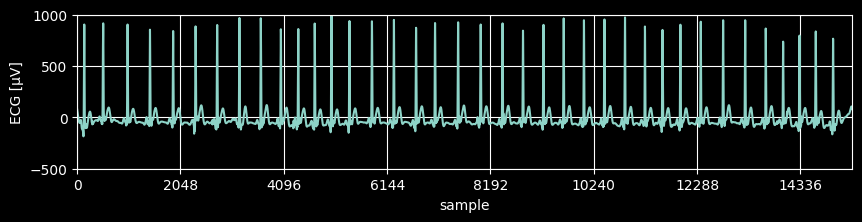

In [33]:
fig = plt.figure(figsize=(10,2))

plt.plot(ekg[0])
plt.xlabel('sample')
plt.xlim(0, 15360)
plt.xticks(np.arange(0, 15360, 512 * 4))
plt.ylabel('ECG [μV]')
plt.ylim(-500, 1000)
plt.grid()

plt.show()

In [34]:
print(f"Liczba próbek: {len(ekg)}")
print(f"Min sample: {ekg.min()}")
print(f"Max sample: {ekg.max()}")

Liczba próbek: 15360
Min sample: 0   -184.41
dtype: float64
Max sample: 0    1007.035
dtype: float64


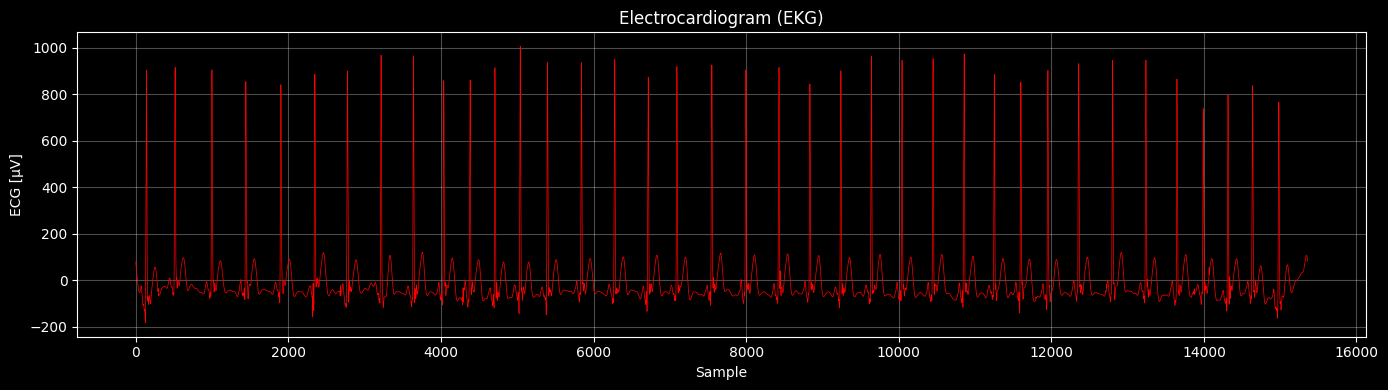

In [35]:
plt.rcParams['font.family'] = 'DejaVu Sans'
fig = plt.figure(figsize=(14, 4))
plt.plot(ekg[0], color='red', linewidth=0.5)
plt.xlabel('Sample')
plt.ylabel('ECG [μV]')
plt.title('Electrocardiogram (EKG)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [36]:
import neurokit2 as nk

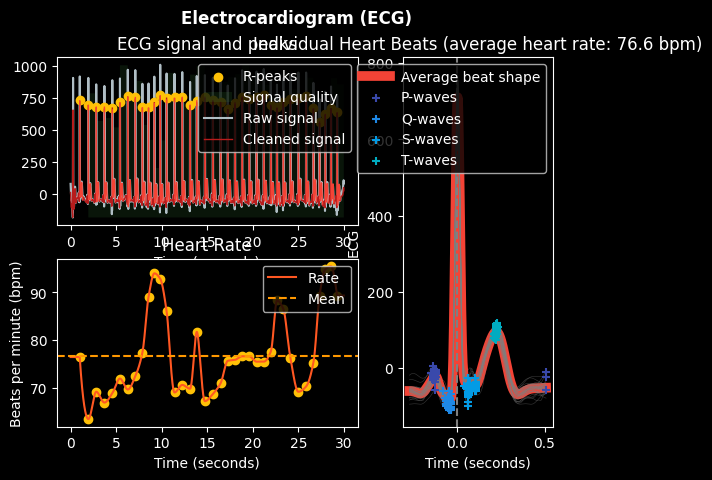

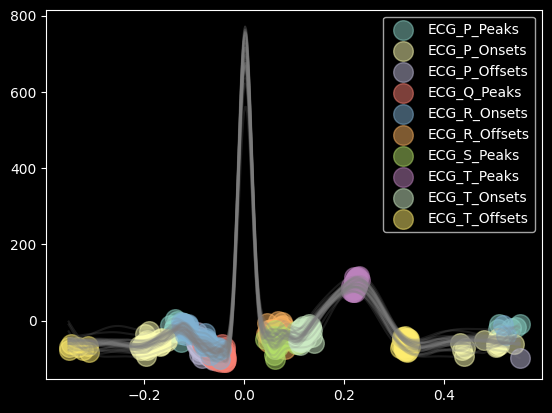

In [37]:
ecg_signal = ekg.iloc[:, 0]

# 2. Czyszczenie sygnału
cleaned = nk.ecg_clean(ecg_signal, sampling_rate=sampling_rate)

# 3. Przetwarzanie sygnału (znajduje załamki R, jakość sygnału itp.)
signals, info = nk.ecg_process(ecg_signal, sampling_rate=sampling_rate)

# Rysowanie standardowego panelu z wynikami
nk.ecg_plot(signals, info)

# 4. Wyznaczenie dokładnych punktów załamków (P, Q, S, T)
# Zamiast całego słownika 'info', bezpieczniej jest przekazać konkretnie załamki R
signal_delineate, waves = nk.ecg_delineate(
    cleaned,
    rpeaks=info["ECG_R_Peaks"],
    sampling_rate=sampling_rate,
    method="dwt",
    show=True,
    show_type='all'
)

plt.show()